# Read training data of forcesmip6 challenge

In [1]:
import os
import netCDF4 as netcdf
import numpy as np
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/src")

PATH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Training-Ext/Amon/tas'

In [2]:
DIR_LIST = os.listdir(PATH)

dic_data = {}
dic_forced_response = {}

# how to center the data with respect to the monthly mean

# 1. calculate the monthly mean
# 2. subtract the monthly mean from the data
# 3. calculate the forced response by averaging over the time dimension

for idx_m, dir in enumerate(DIR_LIST):

    print(f'Processing {idx_m+1}/{len(DIR_LIST)}: {dir}')
    dir_path = os.path.join(PATH, dir)
    file_list = os.listdir(dir_path)

    dic_data[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)
    dic_forced_response[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)

    for idx_f, file in enumerate(file_list):
        print(f'  Processing {idx_f+1}/{len(file_list)}: {file}')
        file_path = os.path.join(dir_path, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        dic_data[dir][idx_f,:,:,:] = np.array(netcdf_file.variables['tas']) 
        for i in range(12):
            dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] = dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(dic_data[dir][idx_f, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        # print(f'  Tas shape: {tas.shape}')
    dic_forced_response[dir][:,:,:,:] = np.nanmean(dic_data[dir], axis=0)
    


Processing 1/5: CESM2
  Processing 1/50: tas_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: tas_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: tas_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: tas_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: tas_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: tas_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: tas_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: tas_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: tas_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: tas_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: tas_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: tas_mon_CESM2_historical_ssp370_

# Get Test data in Evaluation Tier1 

In [3]:
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Evaluation-Tier1/Amon/tas'
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'


DIR_LIST_TEST = os.listdir(PATH_EVAL)
data_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

count = 0
for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        data_test[count,:,:,:] = np.array(netcdf_file.variables['tas'][:]) 
        for i in range(12):
            data_test[count,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[count,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[count, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        print(f'  Tas shape: {data_test[count,:,:,:].shape}')
        
        count += 1


  Processing 6/81: tas_mon_1F.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 12/81: tas_mon_1C.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 16/81: tas_mon_1H.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 26/81: tas_mon_1G.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 40/81: tas_mon_1D.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 52/81: tas_mon_1J.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 58/81: tas_mon_1A.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 60/81: tas_mon_1E.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 71/81: tas_mon_1B.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 77/81: tas_mon_1I.195001-202212.nc
  Tas shape: (876, 72, 144)


In [4]:
# Read the ground truth data

PATH_GROUND_TRUTH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ensmeans-Tier1'

DIR_LIST_GROUND_TRUTH = os.listdir(PATH_GROUND_TRUTH)

data_ground_truth_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

count = 0 
for idx_r, file in enumerate(DIR_LIST_GROUND_TRUTH):

    if file.__contains__('.tas.'):
        
        print(f'  Processing {idx_r+1}: {file}')

        # read the ground truth data
        file_path = os.path.join(PATH_GROUND_TRUTH, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # print(netcdf_file.variables)
        print(np.array(netcdf_file.variables['arr_EM']).shape)

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        data_ground_truth_test[count,:,:,:] = np.array(netcdf_file.variables['arr_EM'])

        for i in range(12):
            data_ground_truth_test[count,np.arange(time.shape[0]) % 12 == i,:,:] = data_ground_truth_test[count,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_ground_truth_test[count, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        print(f'  Tas shape: {data_ground_truth_test[count,:,:,:].shape}')
        count += 1

  Processing 7: 1A.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 15: 1B.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 23: 1C.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 31: 1D.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 39: 1E.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 47: 1F.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 55: 1G.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 63: 1H.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 71: 1J.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)


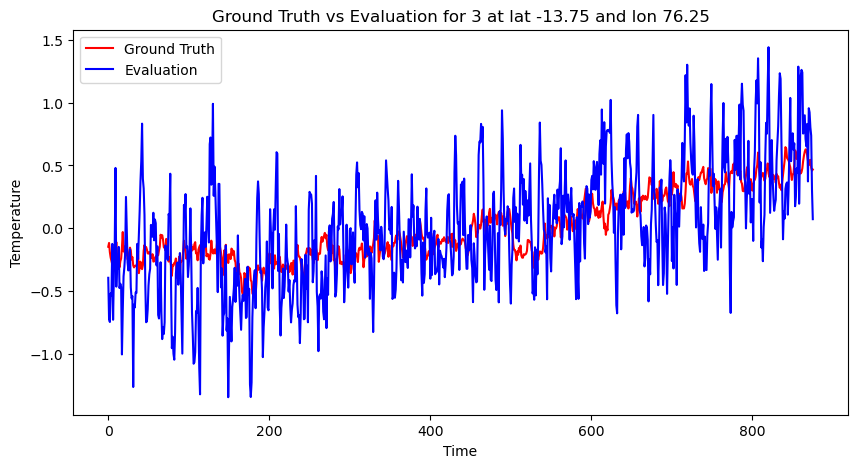

In [5]:
# check if the data is correct by plotting the ensemble mean and the evaluation data on the same plot
import matplotlib.pyplot as plt

idx_run = 3
idx_lat = 30
idx_lon = 30

x_tmp = data_ground_truth_test[idx_run,:,idx_lat,idx_lon]
y_tmp = data_test[idx_run,:,idx_lat,idx_lon]

plt.figure(figsize=(10, 5))
plt.plot(x_tmp, label='Ground Truth', color='red')
plt.plot(y_tmp, label='Evaluation', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

# Merge training data to train the ridge regression model

In [6]:
import torch

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = torch.from_numpy(x[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        y_train[m] = torch.from_numpy(y[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [7]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)


# Compute the yearly average for each key in the dictionary
def compute_yearly_average(data, months_per_year=12):
    """
    Compute the yearly average of a dictionary of numpy arrays.
    Args:
        data: dictionary of numpy arrays
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        dictionary of numpy arrays with yearly averages
    """
    yearly_data = {}
    for key, m in enumerate(data.keys()):
        yearly_data[m] = yearly_average(data[m], months_per_year)

    return yearly_data

In [8]:
# dic_data_tmp = compute_yearly_average(dic_data,  months_per_year=12)
# dic_forced_response_tmp = compute_yearly_average(dic_forced_response, months_per_year=12)
# data_test_tmp = yearly_average(data_test, months_per_year=12)
# data_ground_truth_test_tmp = yearly_average(data_ground_truth_test, months_per_year=12)

In [9]:
# x_tmp = compute_yearly_average(x, months_per_year=12)
# y_tmp = compute_yearly_average(y, months_per_year=12)

In [10]:
# Build training set 
x_train, y_train  = merge_training_data(dic_data,dic_forced_response,dtype=torch.float32)
x, y = reshape_training_data(dic_data,dic_forced_response,dtype=torch.float32)

  x_train shape: torch.Size([132600, 10368])
  x_train shape: torch.Size([198900, 10368])
  x_train shape: torch.Size([278460, 10368])
  x_train shape: torch.Size([411060, 10368])
  x_train shape: torch.Size([490620, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([25, 2652, 10368])
  y_train shape: torch.Size([25, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])


# Train a ridge regression

In [11]:
from algorithms import ridge_regression, ridge_regression_low_rank, train_trace_norm

In [12]:
lambda_tmp = 50000.0

# ridge regression
w_ridge = ridge_regression(x_train, y_train, lambda_= lambda_tmp, verbose=False, dtype=torch.float32)

In [13]:
# low rank regression
# rank = 
# w_ridge_low_rank = ridge_regression_low_rank(x_train, y_train, rank=rank, lambda_=lambda_tmp, verbose=False, dtype=torch.float32)

In [14]:
# Train ridge regression with trace norm regularization

# trace norm regularizer
nu_tmp = 35000.0

w_trace_norm = train_trace_norm(x_train, y_train,lambda_ = lambda_tmp,nu_ = nu_tmp,dtype=torch.float32,verbose=False)

# check the rank of the matrix 
print(f'Rank of the matrix: {torch.linalg.matrix_rank(w_trace_norm)}')

Rank of the matrix: 18


In [15]:
# Evaluate the model on test data
x_test = torch.from_numpy(data_test).to(torch.float32).reshape(data_test.shape[0],data_test.shape[1],longitude.shape[0]*latitude.shape[0])
y_test = torch.from_numpy(data_ground_truth_test).to(torch.float32).reshape(data_test.shape[0],data_test.shape[1],longitude.shape[0]*latitude.shape[0])

# Evaluate the model on test data
y_pred = x_test @ w_ridge
# y_pred_low_rank = x_test @ w_ridge_low_rank
y_pred_trace_norm = x_test @ w_trace_norm


# Compute the mean squared error
rmse = torch.sqrt(torch.mean((y_pred - y_test) ** 2,axis=(1,2))).detach().numpy()
# rmse_low_rank = torch.sqrt(torch.mean((y_pred_low_rank - y_test) ** 2,axis=(1,2))).detach().numpy()
rmse_trace_norm = torch.sqrt(torch.mean((y_pred_trace_norm - y_test) ** 2,axis=(1,2))).detach().numpy()

print(f'  MSE: {rmse}')
# print(f'  MSE low rank: {rmse_low_rank}')
print(f'  MSE trace norm: {rmse_trace_norm}')

  MSE: [0.46039203 0.6263385  0.76128286 0.5452507  0.6579928  0.47486296
 0.56580937 0.40406218 0.56212646 0.62651175]
  MSE trace norm: [0.42051622 0.47521466 0.81091183 0.50624573 0.5341286  0.4672152
 0.57070863 0.33126253 0.50774354 0.49193397]


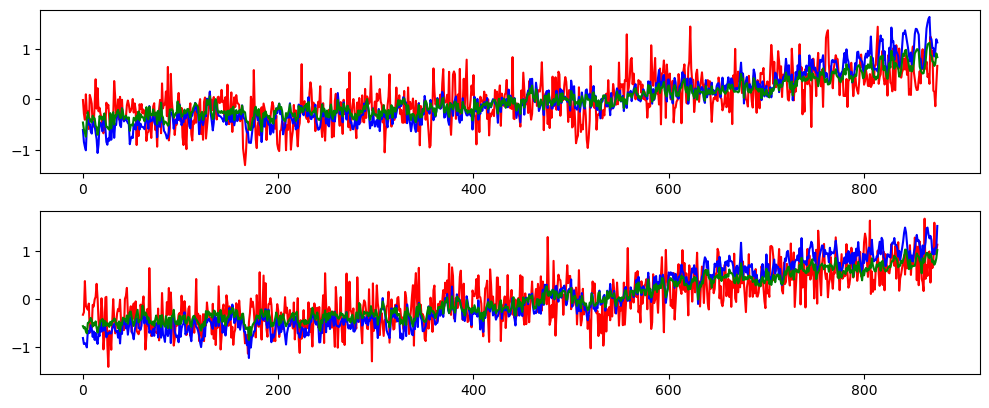

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i in range(2):
    plt.subplot(5, 1, i+1)
    plt.plot(y_test[i,:,100],color='red', label='Ground Truth')
    # plt.plot(y_pred_low_rank[i,:,100])
    plt.plot(y_pred[i,:,100], color='blue', label='Ridge Regression')
    plt.plot(y_pred_trace_norm[i,:,100], color='green', label='Trace Norm')

plt.tight_layout()
plt.show()

# Get the estimates of the other methods

In [17]:
# Read the estimates of the other methods
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/submissions-Tier1-standardized-estimates'


DIR_LIST_TEST = os.listdir(PATH_TEST)
data_estimates = np.zeros((30,10, 876, 72, 144), dtype=np.float32)

count = 0
for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_'):

        # read the test data
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_TEST, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')


        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])
        data_estimates[:,count,:,:,:] = np.array(netcdf_file.variables['forced_component']) 

        print(f'  Tas shape: {data_estimates[:,count,:,:,:].shape}')
        count += 1



  Processing 51/80: tas_1A_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 52/80: tas_1B_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 53/80: tas_1C_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 54/80: tas_1D_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 55/80: tas_1E_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 56/80: tas_1F_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 57/80: tas_1G_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 58/80: tas_1H_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 59/80: tas_1I_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 60/80: tas_1J_1950_2022.nc
  Tas shape: (30, 876, 72, 144)


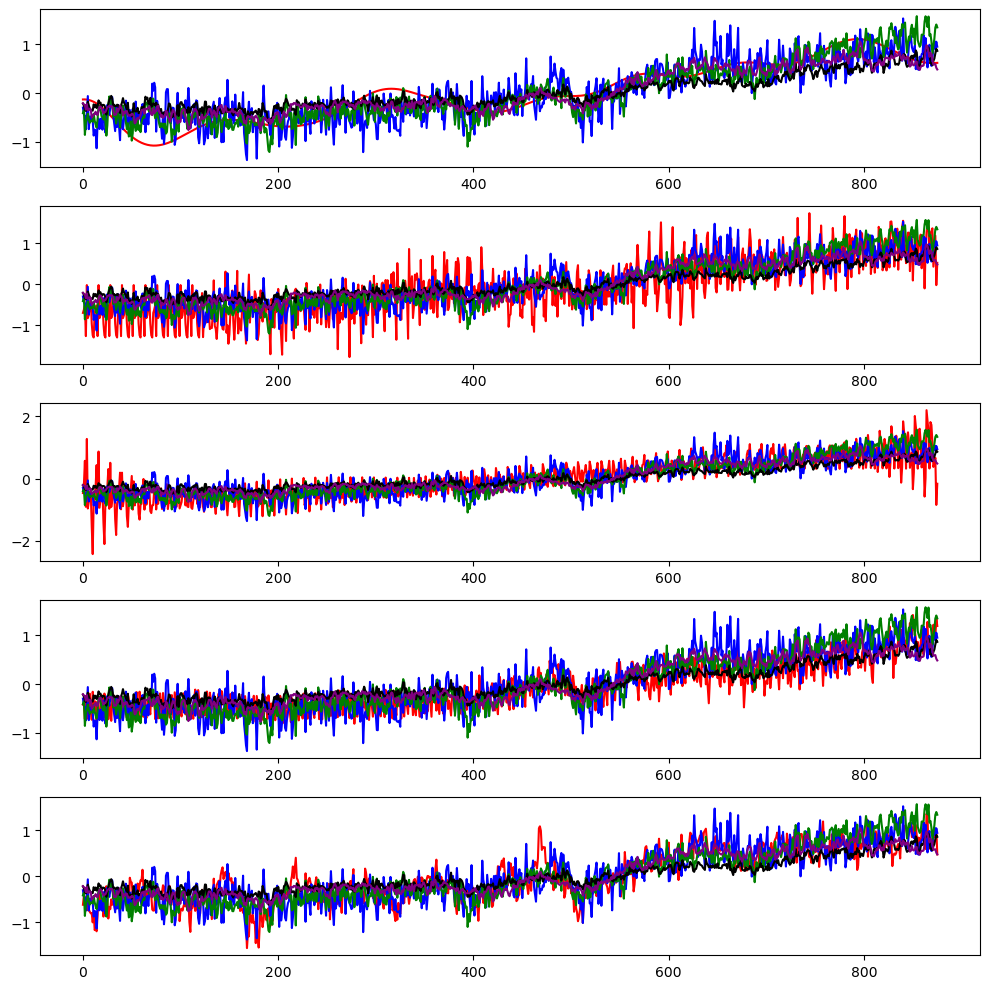

In [18]:
# display the estimates

idx_run = 0


plt.close('all')
plt.figure(figsize=(10, 10))


for i in range(5):
    plt.subplot(5, 1, i+1)
    plt.plot(data_estimates[i,idx_run,:,50,30],color='red')
    plt.plot(data_ground_truth_test[idx_run,:,50,30], color='blue')
    plt.plot(y_pred.reshape(10,y_pred.shape[1],data_estimates.shape[3],data_estimates.shape[4])[idx_run,:,50,30], color='green')
    plt.plot(y_pred_trace_norm.reshape(10,y_pred.shape[1],data_estimates.shape[3],data_estimates.shape[4])[idx_run,:,50,30], color='black', label='Trace Norm')
    plt.plot(data_estimates[29,idx_run,:,50,30],color='purple', label='Good prediction')
plt.tight_layout()
plt.show()

In [19]:
# compute mse of the other estimates
mse_estimates = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))

for idx_r in range(data_estimates.shape[0]):
    mse_estimates[idx_r,:] = np.sqrt(np.mean((data_estimates[idx_r,:,:,:,:] - data_ground_truth_test) ** 2,axis=(1,2,3))) 
    print(f'  MSE estimates: {mse_estimates[idx_r,:]}')

  MSE estimates: [0.49550778 0.51100057 0.67596477 0.84101903 0.48415652 0.47930476
 0.61143172 0.43098748 0.56707537 0.51562512]
  MSE estimates: [0.51639372 0.5460459  0.65299219 0.7674492  0.49941075 0.50957346
 0.57887173 0.46936822 0.65890628 0.57861054]
  MSE estimates: [0.49182796 0.5012449  0.58460832 0.87728935 0.48170397 0.48428568
 0.55289179 0.44784209 0.66019011 0.61788714]
  MSE estimates: [0.43085137 0.56283027 0.78117096 0.44237232 0.5036909  0.4146412
 0.49771696 0.31438255 0.45016742 0.56614858]
  MSE estimates: [0.42836311 0.43215752 0.62536472 0.59834325 0.44574437 0.43019038
 0.52151704 0.38851166 0.47265992 0.4801116 ]
  MSE estimates: [0.36044395 0.38175088 0.56761026 0.45852318 0.4024646  0.35533607
 0.47676918 0.31087133 0.43721801 0.3903268 ]
  MSE estimates: [0.38899282 0.41481045 0.6190955  0.73331398 0.422548   0.38153708
 0.50368208 0.33451095 0.4932439  0.40448675]
  MSE estimates: [0.49169007 0.50437868 0.69514912 0.77526796 0.50779128 0.50623846
 0.5940

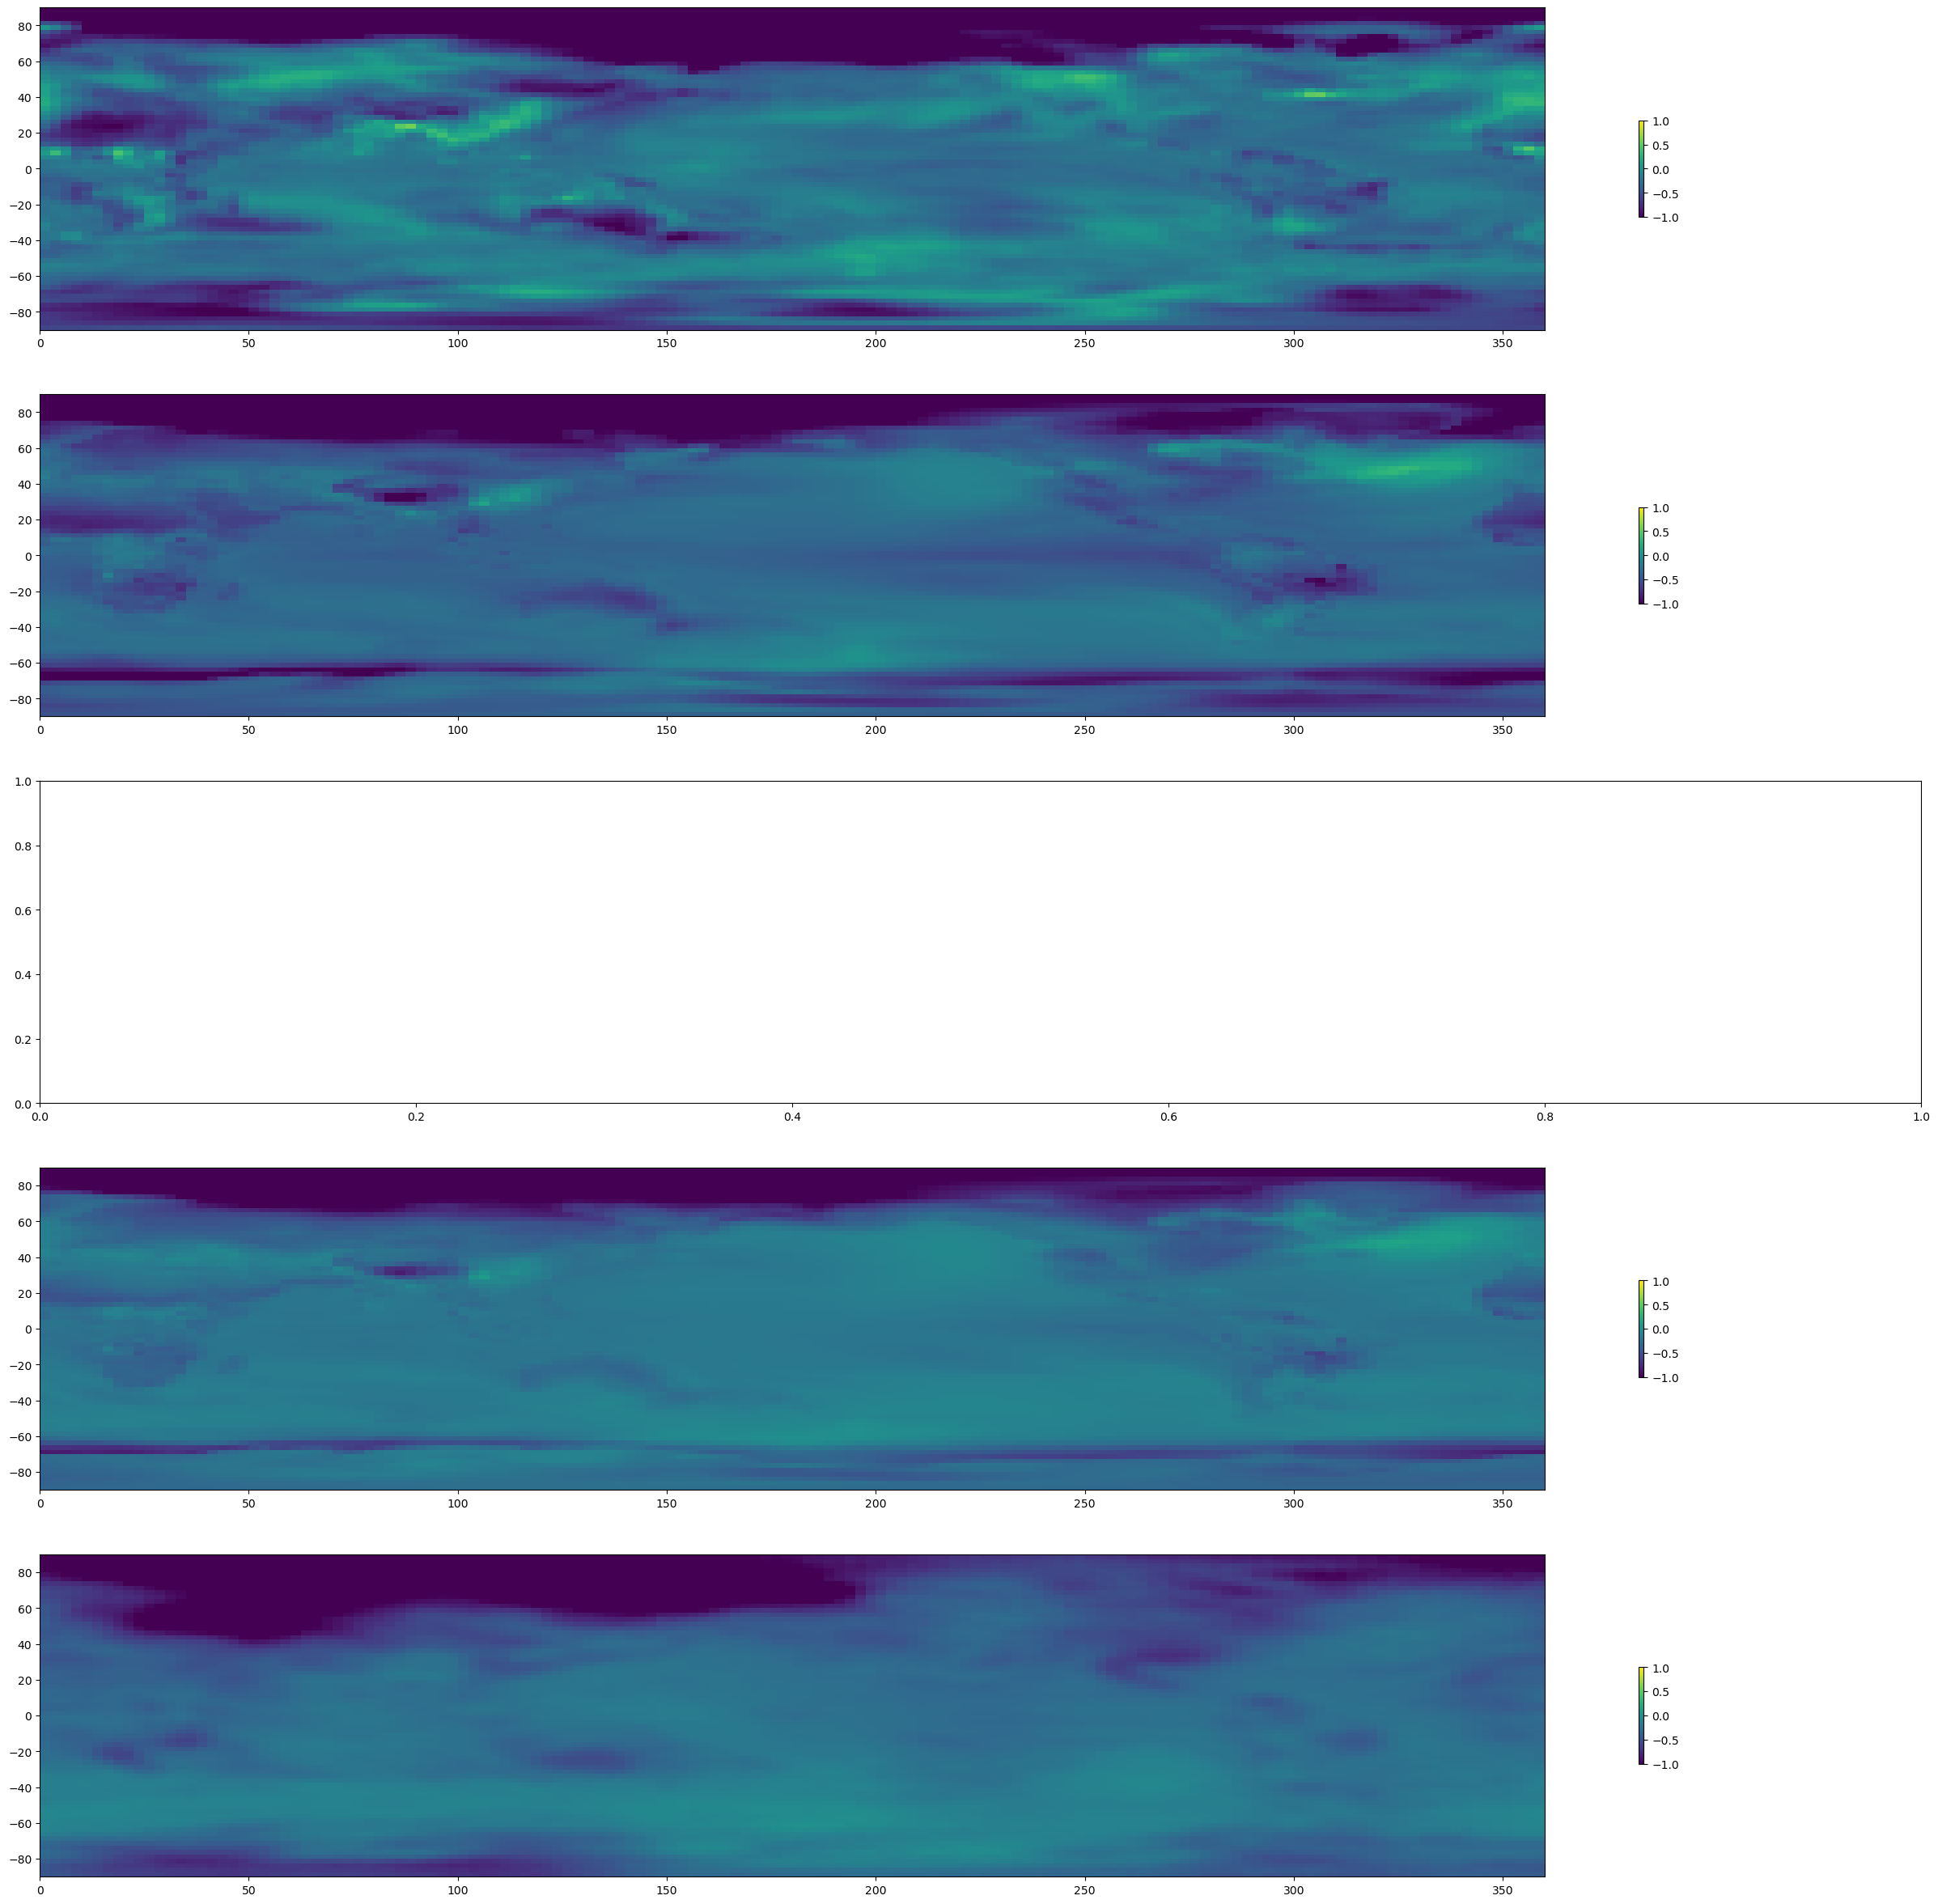

In [20]:
lat_grid, lon_grid = np.meshgrid(latitude , longitude, indexing='ij')

# reshape the groundtruth data to the original shape
y_test_tmp = y_test.reshape(10,y_test.shape[1],latitude.shape[0],longitude.shape[0]).detach().numpy()

# reshape the predictions to the original shape
y_pred_tmp = y_pred.reshape(10,y_pred.shape[1],latitude.shape[0],longitude.shape[0]).detach().numpy()
# y_pred_low_rank_tmp = y_pred_low_rank.reshape(10,y_pred.shape[1],latitude.shape[0],longitude.shape[0]).detach().numpy()
y_pred_trace_norm_tmp = y_pred_trace_norm.reshape(10,y_pred.shape[1],latitude.shape[0],longitude.shape[0]).detach().numpy()

# get index of the first run
idx_run = 0


# plot the earth color map
fmin = -1.0
fmax = 1.0

fig, ax = plt.subplots(5, 1, figsize=(30, 30))
im0 = ax[0].pcolormesh(lon_grid, lat_grid, y_test_tmp[0,10,:,:] , vmin=fmin, vmax=fmax)
plt.colorbar(im0, ax=ax[0], shrink=0.3)

im1 = ax[1].pcolormesh(lon_grid, lat_grid, y_pred_tmp[0,10,:,:] , vmin=fmin, vmax=fmax)
plt.colorbar(im1, ax=ax[1], shrink=0.3)


# im2 = ax[2].pcolormesh(lon_grid, lat_grid, y_pred_low_rank_tmp[0,10,:,:] , vmin=fmin, vmax=fmax)
# plt.colorbar(im2, ax=ax[2], shrink=0.3)


im3 = ax[3].pcolormesh(lon_grid, lat_grid, y_pred_trace_norm_tmp[0,10,:,:] , vmin=fmin, vmax=fmax)
plt.colorbar(im3, ax=ax[3], shrink=0.3)


im4 = ax[4].pcolormesh(lon_grid, lat_grid, data_estimates[29,0,10,:,:] , vmin=fmin, vmax=fmax)
plt.colorbar(im4, ax=ax[4], shrink=0.3)

In [21]:
# get the statistics of the estimates and the predictions
stats_mse_estimates = {}
stats_mse_estimates['mean'] = np.zeros(mse_estimates.shape[0]+3)
stats_mse_estimates['median'] = np.zeros(mse_estimates.shape[0]+3)
stats_mse_estimates['75th'] = np.zeros(mse_estimates.shape[0]+3)
stats_mse_estimates['90th'] = np.zeros(mse_estimates.shape[0]+3)
stats_mse_estimates['95th'] = np.zeros(mse_estimates.shape[0]+3)
stats_mse_estimates['worst-case'] = np.zeros(mse_estimates.shape[0]+3)

# compute also the variance of mse estimates
stats_mse_estimates['variance'] = np.zeros(mse_estimates.shape[0]+3)


for idx_r in range(data_estimates.shape[0]):
    # compute the mse of the estimates

    stats_mse_estimates['mean'][idx_r] = np.mean(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['median'][idx_r] = np.median(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['75th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.75, axis=0)
    stats_mse_estimates['90th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.90, axis=0)
    stats_mse_estimates['95th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.95, axis=0)
    stats_mse_estimates['worst-case'][idx_r] = np.max(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['variance'][idx_r] = np.var(mse_estimates[idx_r,:], axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]] = np.mean(rmse, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]] = np.median(rmse, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]] = np.quantile(rmse, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]] = np.quantile(rmse, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]] = np.quantile(rmse, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]] = np.max(rmse, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]] = np.var(rmse, axis=0)


# stats_mse_estimates['mean'][data_estimates.shape[0]+1] = np.mean(rmse_low_rank, axis=0)
# stats_mse_estimates['median'][data_estimates.shape[0]+1] = np.median(rmse_low_rank, axis=0)
# stats_mse_estimates['75th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.75, axis=0)
# stats_mse_estimates['90th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.90, axis=0)
# stats_mse_estimates['95th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.95, axis=0)
# stats_mse_estimates['worst-case'][data_estimates.shape[0]+1] = np.max(rmse_low_rank, axis=0)
# stats_mse_estimates['variance'][data_estimates.shape[0]+1] = np.var(rmse_low_rank, axis=0)

stats_mse_estimates['mean'][data_estimates.shape[0]+2] = np.mean(rmse_trace_norm, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+2] = np.median(rmse_trace_norm, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+2] = np.quantile(rmse_trace_norm, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+2] = np.quantile(rmse_trace_norm, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+2] = np.quantile(rmse_trace_norm, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+2] = np.max(rmse_trace_norm, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+2] = np.var(rmse_trace_norm, axis=0)



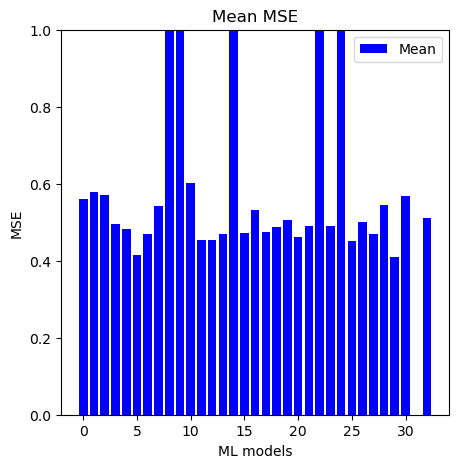

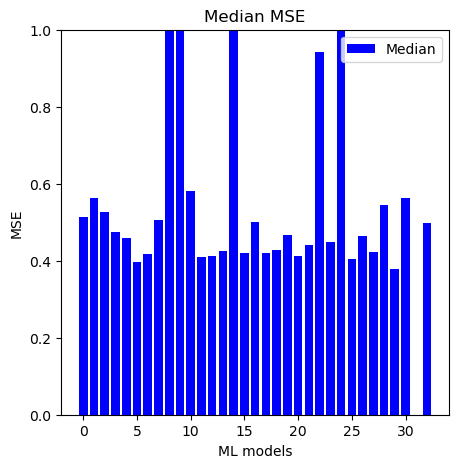

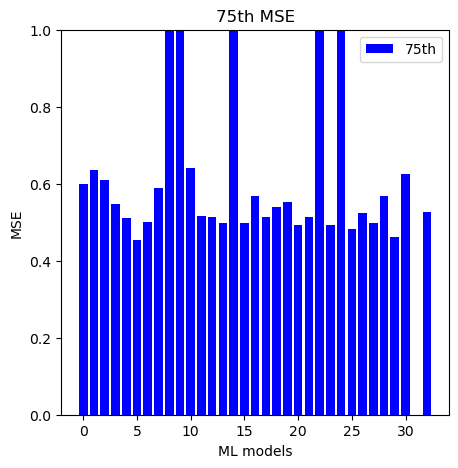

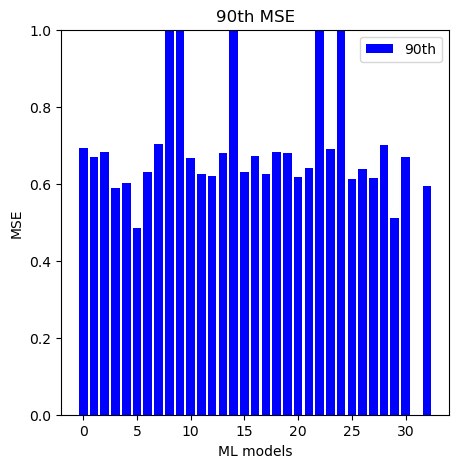

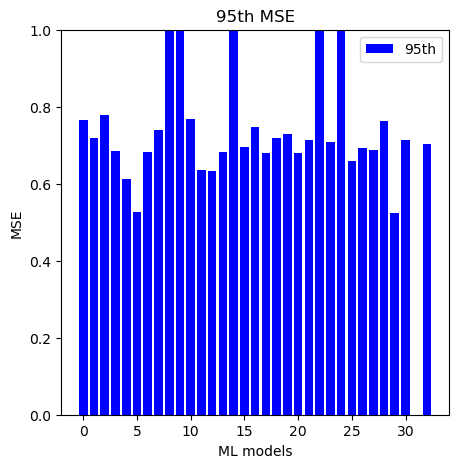

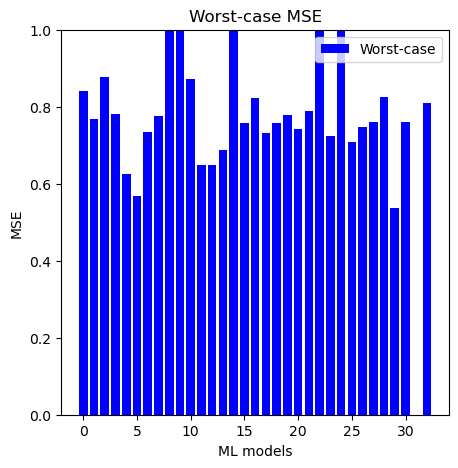

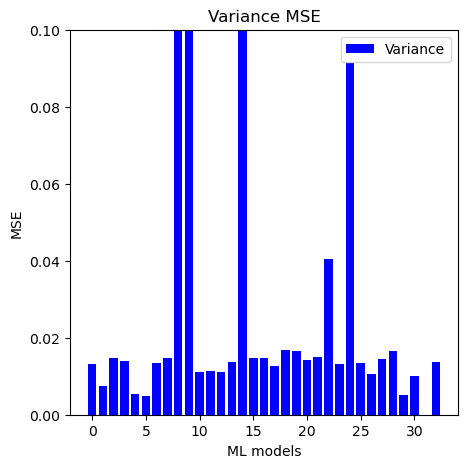

In [ ]:
# display the statistica as bar plot

#plot the mean
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['mean'])), stats_mse_estimates['mean'], color='blue', label='Mean')
plt.title('Mean MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the median
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['median'])), stats_mse_estimates['median'], color='blue', label='Median')
plt.title('Median MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the 75th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['75th'])), stats_mse_estimates['75th'], color='blue', label='75th')
plt.title('75th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 90th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['90th'])), stats_mse_estimates['90th'], color='blue', label='90th')
plt.title('90th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 95th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['95th'])), stats_mse_estimates['95th'], color='blue', label='95th')
plt.title('95th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

# plot the worst-case
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['worst-case'])), stats_mse_estimates['worst-case'], color='blue', label='Worst-case')
plt.title('Worst-case MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()


# plot the variance
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['variance'])), stats_mse_estimates['variance'], color='blue', label='Variance')
plt.title('Variance MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0,0.1)
plt.legend()
plt.show()

In [23]:
stats_mse_estimates['mean'][-1]

0.5115880370140076

In [29]:
stats_mse_estimates['mean'][-8]

0.4501733332872391